Capston Data Project - Black Box Optimization.

Comment in if running from google CoLab for example, set the path to the project directory.

In [1]:
# If running from google CoLab, install the required packages
#from google.colab import drive
#drive.mount('/content/drive')

#import os
#import sys
#project_path = '/content/drive/MyDrive/CAPSTONE_PROJECT/project'
#sys.path.append(project_path)

# Change the current working directory to the project root
#os.chdir(project_path)

Import libraries

In [ ]:
import numpy as np
from scipy.stats import norm, qmc
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process import GaussianProcessRegressor

# Data loading functions for loading data, appending new data
from src.data_loading import load_initial_data, append_input_and_output_data

# Aquisition functions for calculating the next point to sample
from src.acquisition_functions import ucb, expected_improvement, probability_improvement, normalize_score

# SVM classifier for filtering high-yield samples
from src.svm_filter import (train_svm_high_yield_classifier, filter_candidates_with_svm, 
mix_svm_candidates_with_global_exploration, plot_svm_decision_boundary_matrix)

# Hyperparameter tuning for Gaussian Process Regression
from src.gp_hyperparameter_tuning import make_gp_kernel, tune_gp_hyperparameters

# Neural-network surrogate candidate generator
try:
    from src.neural_surrogate import (
        NeuralSurrogateCandidateGenerator,
        print_nn_candidate_report,
    )
except ModuleNotFoundError:
    from src.neural_surrogate import (
        NeuralSurrogateCandidateGenerator,
        print_nn_candidate_report,
    )


Data set/Function and week appended data:

Choose a data set - function integer value 1-8

Choose a week number integer 0-n to append upto 'n' weeks of data

In [3]:
# Change here 'load_dataset' is the function number 1-8
load_dataset = 5
# Change here to load upto 'week_dataset' additional data
week_dataset = 4

Load initial data for the selected function and report stats.

In [4]:
# Load initial data for function number : load_dataset
function_Inputs, function_Outputs = load_initial_data(load_dataset)

# Record the initial number of data points for later use in candidate generation
initial_num_points = function_Inputs.shape[0]

# Mark originaL DATA MAX OUTPUT
original_max_output = function_Outputs.max()

# View the data
print("max and min of function outputs")
print("Max:", function_Outputs.max())
print("Min:", function_Outputs.min())
print(function_Inputs.shape)
print(function_Outputs.shape)
print("Function Inputs:")
print(function_Inputs)
print("Function Outputs:")    
print(function_Outputs)

max and min of function outputs
Max: 1088.8596181962705
Min: 0.1129397953712203
(20, 4)
(20,)
Function Inputs:
[[0.19144708 0.03819337 0.60741781 0.41458414]
 [0.75865295 0.53651774 0.65600038 0.36034155]
 [0.43834987 0.8043397  0.21024527 0.15129482]
 [0.70605083 0.53419196 0.26424335 0.48208755]
 [0.83647799 0.19360965 0.6638927  0.78564888]
 [0.68343225 0.11866264 0.82904591 0.56757661]
 [0.55362148 0.66734998 0.32380582 0.81486975]
 [0.35235627 0.32224153 0.11697937 0.47311252]
 [0.15378571 0.72938169 0.42259844 0.44307417]
 [0.46344227 0.63002451 0.10790646 0.9576439 ]
 [0.67749115 0.35850951 0.47959222 0.07288048]
 [0.58397341 0.14724265 0.34809746 0.42861465]
 [0.30688872 0.31687813 0.62263448 0.09539906]
 [0.51114177 0.817957   0.72871042 0.11235362]
 [0.43893338 0.77409176 0.37816709 0.93369621]
 [0.22418902 0.84648049 0.87948418 0.87851568]
 [0.72526172 0.47987049 0.08894684 0.75976022]
 [0.35548161 0.63961937 0.41761768 0.12260384]
 [0.11987923 0.86254031 0.64333133 0.849803

Append upto week number 'n' : week_dataset and report stats. 

In [5]:
# Append new data from the specified week(s)
# Append new data from week 1 if week_dataset is 1 or higher, 
# and from week 2 if week_dataset is 2 or higher, and so on up to week 13
# This allows for cumulative loading of data from multiple weeks based on the user's selection.

function_Inputs, function_Outputs = append_input_and_output_data(
    function_Inputs, 
    function_Outputs, 
    week_dataset, 
    position=load_dataset-1, 
    prevent_duplicates=False
    )


# Print max and min of function outputs after appending new data
print("\n")
print("Max and Min of function outputs")
print("Max:", function_Outputs.max())
print("Min:", function_Outputs.min(), "\n")

# print out the last 'week_dataset' outputs
# This will show the outputs from the most recently appended data, which can help 
# verify that the new data has been added correctly and to understand the range 
# of outputs being added.
print("New Outputs outputs:")
print(function_Outputs[-week_dataset:])

# Print the shapes of the function inputs and outputs after appending new data
print("\n")
print("Function Shape after appending new data:")
print(function_Inputs.shape)
print(function_Outputs.shape)

#look at the data
print("\n")
print("Function Inputs:")
print(function_Inputs)
print("Function Outputs:")    
print(function_Outputs)

newOutputs = function_Outputs[-week_dataset:]
#append the original max value to the new outputs for comparison
newOutputs = np.append(newOutputs, original_max_output)


Appended position 4 which is data from data/new_data/inputs_week1.txt for Function 5.
Appended position 4 which is data from data/new_data/inputs_week2.txt for Function 5.
Appended position 4 which is data from data/new_data/inputs_week3.txt for Function 5.
Appended position 4 which is data from data/new_data/inputs_week4.txt for Function 5.


Max and Min of function outputs
Max: 4799.02151222899
Min: 0.1129397953712203 

New Outputs outputs:
[1103.27296845 3149.29516064 4235.51393159 4799.02151223]


Function Shape after appending new data:
(24, 4)
(24,)


Function Inputs:
[[0.19144708 0.03819337 0.60741781 0.41458414]
 [0.75865295 0.53651774 0.65600038 0.36034155]
 [0.43834987 0.8043397  0.21024527 0.15129482]
 [0.70605083 0.53419196 0.26424335 0.48208755]
 [0.83647799 0.19360965 0.6638927  0.78564888]
 [0.68343225 0.11866264 0.82904591 0.56757661]
 [0.55362148 0.66734998 0.32380582 0.81486975]
 [0.35235627 0.32224153 0.11697937 0.47311252]
 [0.15378571 0.72938169 0.42259844 0.443074

Look at raw function outputs and see new appended outputs

Function  5 Output range:
Min: 0.1129397953712203
Max: 4799.02151222899
Mean: 679.6892119370661


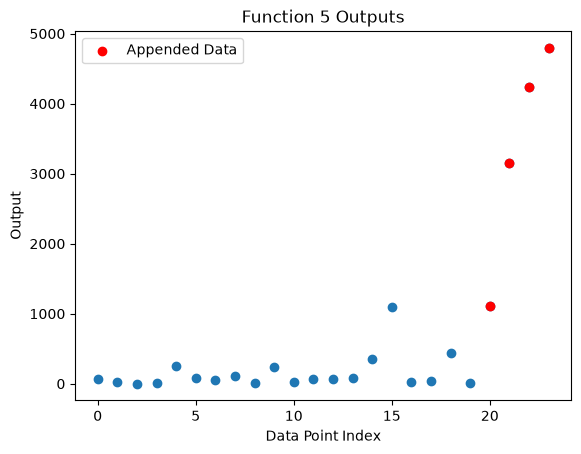

In [6]:
#look at the output data
print("Function ", load_dataset, "Output range:")
print("Min:", np.min(function_Outputs))
print("Max:", np.max(function_Outputs))
print("Mean:", np.mean(function_Outputs))
    
#just visualis the outputs
plt.scatter(range(len(function_Outputs)), function_Outputs)
# plot the appended data points in a different color to see where they are in the output space
if week_dataset > 0:
    plt.scatter(range(len(function_Outputs)-week_dataset, len(function_Outputs)), function_Outputs[-week_dataset:], color='red', label='Appended Data')
    plt.legend()
plt.xlabel('Data Point Index')
plt.ylabel('Output')
plt.title('Function ' + str(load_dataset) + ' Outputs')
plt.show()

Define X input data and y output data, n.b output data may need transforming. 

This section applies different transformations to the output data based on the dataset being loaded,<br>
such as inversion, log transform, or no transform, to ensure that the optimization process is focused <br>
on maximizing the desired objective, whether it's contamination score, yield, model performance, or<br> 
other metrics, while also handling cases where the raw outputs may need to be transformed to be more<br> 
suitable for optimization (e.g., converting a minimization problem into a maximization one, or applying a log transform to handle skewed data).


In [7]:
# X is input data
X = np.asarray(function_Inputs)

# y is output data
raw_y = np.asarray(function_Outputs).ravel()

if load_dataset == 1:
    # FUNCTION1: Contamination Score Dataset
    # For the contamination score dataset, we want to maximize the score, so we invert it by negating the raw outputs.
    # Additionally, we apply a log transform to handle skewness and ensure that the optimization focuses on maximizing 
    # the score effectively, while also ensuring that we only take the log of non-negative values by applying np.maximum 
    # to set any negative values to zero before the log transform.
    y = np.abs(raw_y.astype(float))
    y = np.log1p(y)
    output_transform = "contamination_score_inversion_and_log_transform"
    # Get the indices of the largest 2 values in y
    #largest_indices = np.argsort(y)[-2:]
    # Remove the largest 2 values and their corresponding inputs
    #X = np.delete(X, largest_indices, axis=0)
    #y = np.delete(y, largest_indices, axis=0)

elif load_dataset == 2:
    # FUNCTION2: Raw Output Maximization Dataset
    # For the dataset where we want to maximize the raw outputs directly, we simply convert the raw outputs to 
    # float without any transformation, allowing the optimization process to focus on maximizing the original values as they are.
    y = raw_y.astype(float)
    output_transform = "maximisation_no_transform"

elif load_dataset == 3:
    # FUNCTION3: Side Effects Minimization Dataset
    # For the side effects dataset, we want to minimize the side effects, which is equivalent to maximizing the negative of the raw outputs.
    y = -raw_y.astype(float)
    output_transform = "negative_side_effects_maximisation_inversion"

elif load_dataset == 4:
    # FUNCTION4: Baseline Difference Maximization Dataset
    # For the baseline difference dataset, we want to maximize the difference from the baseline, which is equivalent to 
    # maximizing the raw outputs directly, so we simply convert the raw outputs to float without any transformation.
    y = raw_y.astype(float)
    output_transform = "baseline_difference_maximisation"

elif load_dataset == 5:
    # FUNCTION5: Yield Maximization Dataset
    # For the yield dataset, we want to maximize the yield, which is equivalent to maximizing the raw outputs directly,
    # so we simply convert the raw outputs to float without any transformation.
    y = raw_y.astype(float)
    output_transform = "yield_maximisation"

elif load_dataset == 6:
    # FUNCTION6: Total Penalty Minimization Dataset
    # For the total penalty dataset, we want to minimize the total penalty, which is equivalent to maximizing the negative of the raw outputs.
    y = -raw_y.astype(float)
    output_transform = "negative_total_penalty_maximisation_inversion"

elif load_dataset == 7:
    # FUNCTION7: Model Performance Maximization Dataset
    # For the model performance dataset, we want to maximize the model performance, which is equivalent to maximizing the raw outputs directly,
    # so we simply convert the raw outputs to float without any transformation.
    y = raw_y.astype(float)
    output_transform = "model_performance_maximisation"

elif load_dataset == 8:
    # FUNCTION8: High-Dimensional Maximization Dataset
    # For the high-dimensional maximization dataset, we want to maximize the raw outputs directly, so we simply convert the raw outputs to float without any transformation.
    y = raw_y.astype(float)
    output_transform = "high_dimensional_maximisation"

else:
    # For any other dataset, we default to no transformation and simply convert the raw outputs to float, allowing the optimization process to focus on maximizing the original values as they are.
    y = raw_y.astype(float)
    output_transform = "none"

# -----------------------------------------------------------
# Basic checks on input and output dimensions and sample size
# -----------------------------------------------------------
if X.ndim != 2:
    raise ValueError("function_Inputs must be a 2D array")

if y.ndim != 1:
    raise ValueError("function_Outputs must be a 1D array")

if len(X) != len(y):
    raise ValueError(f"Input/output mismatch: " f"X has {len(X)} rows, " f"y has {len(y)} rows")

n_samples = X.shape[0]
n_dimensions = X.shape[1]

if n_dimensions < 2 or n_dimensions > 8:
    raise ValueError(f"This code expects 2 to 8 input dimensions, " f"got {n_dimensions}")

# Print the type of output transformation applied for clarity and debugging purposes, 
# so that we can easily understand how the raw outputs were transformed for optimization 
# based on the dataset being loaded.
print(f"Output transformation applied: {output_transform}")
print(f"Number of samples: {n_samples}")
print(f"Input dimensions: {n_dimensions}")
print(f"Samples per dimension: {n_samples / n_dimensions:.4f}")

Output transformation applied: yield_maximisation
Number of samples: 24
Input dimensions: 4
Samples per dimension: 6.0000


Optional enable and setup an SVM high-yield region filter

This is useful for functions where the interesting high-output region is small.<br>
It labels the top N% of observed outputs as "high yield", trains an RBF SVM classifier,<br>
scores the generated candidate pool, and keeps only the candidates most likely to be high yield.

In [8]:
# Turn it on/off per function here.
use_svm_filter_by_function = {
    1: True,
    2: True,
    3: True,
    4: True,
    5: True,
    6: False,
    7: True,
    8: True,
}

# SVM label mode per function:
#   "threshold"  -> high-yield if transformed y > svm_threshold
#   "percentile" -> high-yield if transformed y is in the top percentage
# Dataset 1 is very sparse after y = log1p(abs(raw_y)), so a fixed threshold is better.
svm_label_mode_by_function = {
    1: "threshold",
    7: "percentile",
}

# Fixed transformed-y threshold used when svm_label_mode == "threshold".
# For dataset 1 this separates the meaningful contamination region from near-zero values.
svm_threshold_by_function = {
    1: 1e-9,#1e-5,
}

# Fraction of observed data that is labelled high-yield when svm_label_mode == "percentile".
# 0.25 means top 25% = high yield, bottom 75% = low yield.
svm_high_yield_percent_by_function = {
    1: 0.25,
    2: 0.25,
    3: 0.25,
    4: 0.25,
    5: 0.25,
    6: 0.25,
    7: 0.15,
    8: 0.25,
}

# Fraction of generated candidates to keep after SVM scoring.
# This caps the number of candidates kept after applying the probability threshold.
svm_candidate_keep_fraction_by_function = {
    1: 0.30,
    2: 0.50,
    3: 0.50,
    4: 0.50,
    5: 0.35,
    6: 0.50,
    7: 0.10,
    8: 0.50,
}

# Minimum SVM probability required for a candidate to be treated as high-yield.
# If too few candidates pass this threshold, the code falls back to the best min_keep candidates.
svm_min_probability_by_function = {
    1: 0.25,
    2: 0.60,
    3: 0.60,
    4: 0.60,
    5: 0.60,
    6: 0.60,
    7: 0.60,
    8: 0.60,
}

# Minimum number of candidates to keep if the SVM probability threshold is too strict.
svm_min_keep_candidates_by_function = {
    1: 5000,
    2: 10000,
    3: 10000,
    4: 10000,
    5: 10000,
    6: 10000,
    7: 3000,
    8: 10000,
}

# Fraction of additional global candidates to mix back in after SVM filtering.
# This prevents the SVM from becoming a hard gate and missing undiscovered high-value islands.
# Dataset 1 uses a soft SVM guide plus 30% global exploration.
svm_random_exploration_fraction_by_function = {
    1: 0.30,
    2: 0.30,
    3: 0.30,
    4: 0.30,
    5: 0.30,
    6: 0.30,
    7: 0.30,
    8: 0.30,
}

svm_enabled = bool(use_svm_filter_by_function.get(load_dataset, False))
svm_label_mode = str(svm_label_mode_by_function.get(load_dataset, "percentile"))
svm_threshold_value = float(svm_threshold_by_function.get(load_dataset, 1e-5))
svm_high_yield_percent = float(svm_high_yield_percent_by_function.get(load_dataset, 0.25))
svm_keep_fraction = float(svm_candidate_keep_fraction_by_function.get(load_dataset, 0.50))
svm_min_probability = float(svm_min_probability_by_function.get(load_dataset, 0.60))
svm_min_keep_candidates = int(svm_min_keep_candidates_by_function.get(load_dataset, 10000))
svm_random_exploration_fraction = float(svm_random_exploration_fraction_by_function.get(load_dataset, 0.00))
svm_plot_boundary = bool(use_svm_filter_by_function.get(load_dataset, False))

# Safety clamps.
if svm_label_mode not in {"threshold", "percentile"}:
    svm_label_mode = "percentile"
svm_high_yield_percent = float(np.clip(svm_high_yield_percent, 0.05, 0.50))
svm_keep_fraction = float(np.clip(svm_keep_fraction, 0.05, 1.00))
svm_min_probability = float(np.clip(svm_min_probability, 0.01, 0.99))
svm_min_keep_candidates = max(1, svm_min_keep_candidates)
svm_random_exploration_fraction = float(np.clip(svm_random_exploration_fraction, 0.0, 1.0))

print("\n================ SVM HIGH-YIELD FILTER CONFIG ================\n")
if svm_enabled:
    print(f"SVM filtering is enabled for function {load_dataset}.")
    print(f"SVM label mode: {svm_label_mode}")
    if svm_label_mode == "threshold":
        print(f"High-yield label threshold: transformed y > {svm_threshold_value:.6g}")
    else:
        print(f"High-yield label percentage: top {100.0 * svm_high_yield_percent:.1f}%")
    print(f"Candidate keep fraction cap: {100.0 * svm_keep_fraction:.1f}%")
    print(f"Candidate minimum SVM probability: {svm_min_probability:.2f}")
    print(f"Candidate fallback minimum keep count: {svm_min_keep_candidates}")
    print(f"Random global exploration mix after SVM: {100.0 * svm_random_exploration_fraction:.1f}%")
    print(f"Plot SVM decision boundary: {svm_plot_boundary}")
else:
    print(f"SVM filtering NOT enabled for function {load_dataset}.")


================ SVM HIGH-YIELD FILTER CONFIG ================

SVM filtering is enabled for function 5.
SVM label mode: percentile
High-yield label percentage: top 25.0%
Candidate keep fraction cap: 35.0%
Candidate minimum SVM probability: 0.60
Candidate fallback minimum keep count: 10000
Random global exploration mix after SVM: 30.0%
Plot SVM decision boundary: True


Adaptive exploration vs exploitation weights :

Total of 16 weeks worth of new data allowing us to move from exploration to exploitation over time unless analysis suggests otherwise.

In [9]:
# Set adaptive exploration vs exploitation weights based on the current number of samples 
# and dimensions to balance the acquisition functions according to the stage of exploitation
# and the complexity of the input space. The weights will shift from more exploration (UCB) 
# to more exploitation (EI) as more samples are collected, with the transition happening 
# earlier for higher dimensions where exploration is more important due to the larger 
# input space and slower learning.
n_current = X.shape[0]
n_initial = initial_num_points
# set based on expected total budget of 13 new samples for the whole project
n_remaining_budget = 14-week_dataset
# Calculate progress as the fraction of the remaining budget that has been used, and clip to [0, 1] 
# to avoid issues with negative progress or exceeding the budget
progress = (n_current - n_initial) / n_remaining_budget
progress = np.clip(progress, 0.0, 1.0)
# Set exploration and optimization weights based on progress and dimensionality, 
# with more exploration in higher dimensions and earlier stages of optimization
if n_dimensions >= 5:
    exploration_start = 0.90
    exploration_end = 0.35
else:
    exploration_start = 0.80
    exploration_end = 0.25

# Calculate the exploration weight as a linear interpolation between the start and end values based on progress, 
# and calculate the exploitation weight as the complement of the exploration weight
# TODO maybe later consider a non-linear schedule for the weights, such as exponential decay or a sigmoid function, 
# to allow for a more gradual transition between exploration and exploitation based on the stage of optimization 
# and the complexity of the input space.
exploration_weight = (exploration_start * (1.0 - progress) + exploration_end * progress)
exploitation_weight = 1.0 - exploration_weight

#######################
# MJH LOOK AT THIS ... 
#######################

y_range = np.max(y) - np.min(y)
# Set xi for EI based on exploration weight to encourage more exploration when samples per dimension is low
#if n_samples / n_dimensions < 5:
#    xi = 0.1 * y_range * (1.0 - exploration_weight)
#else:
#    xi = 0.01 * y_range * (1.0 - exploration_weight)

xi = 0.01*y_range

print("\n================ ACQUISITION FUNCTION WEIGHTS ================\n")
print(f"Progress: {progress:.4f} week dataset {week_dataset} / 13 total budget")
print(f"Exploration weight (UCB): {exploration_weight:.3f}")
print(f"Exploitation weight (EI): {exploitation_weight:.3f}")
print(f"\nEI exploration parameter xi: {xi:.6g}")
print(f"potential other xi : {0.01 * y_range:.4f}")



================ ACQUISITION FUNCTION WEIGHTS ================

Progress: 0.4000 week dataset 4 / 13 total budget
Exploration weight (UCB): 0.580
Exploitation weight (EI): 0.420

EI exploration parameter xi: 47.9891
potential other xi : 47.9891


Candidate generation :
- Scale number of candidates with dimensions
- Cap to a reasonable range to avoid too few in low dimensions and too many in high dimensions
- Generate using Latin Hypercube Sampling for better coverage of the input space

In [10]:
# scale candidates with dimensions, but cap to avoid excessive computation
num_candidates = int(50000 * (n_dimensions ** 1.5)) #was 1.5

# cap candidates to a reasonable range to avoid too few in low dimensions or too many in high dimensions 
num_candidates = int(np.clip(num_candidates, 50000, 1000000)) #was 1000000

#Generate candidates using Latin Hypercube Sampling for better coverage of the input space
sampler = qmc.LatinHypercube(d=n_dimensions,seed=0)

#Generate candidates in the unit hypercube and then scale to the input space of X
candidates = sampler.random(num_candidates)

print(f"Generating {num_candidates} candidates for {n_dimensions} dimensions using Latin Hypercube Sampling...")

Generating 400000 candidates for 4 dimensions using Latin Hypercube Sampling...


Optional SVM candidate filtering :

- if SVM is on candidates are filtered according to a SVM high yield classifier.

TODO LOOK AT SCALING ?????????


================ SVM HIGH-YIELD FILTER APPLIED ================

SVM label mode: percentile
High-yield threshold in transformed y-space: 374.758
Observed high-yield samples: 6 / 24
Candidates before SVM filter: 400000
Candidates after SVM probability/fallback filter: 15024
Random global exploration candidates added: 4508
Candidates after SVM + random exploration mix: 19370
SVM minimum probability threshold: 0.6000
SVM minimum fallback keep count: 10000
Kept candidate SVM probability range: 0.0652 to 0.8695


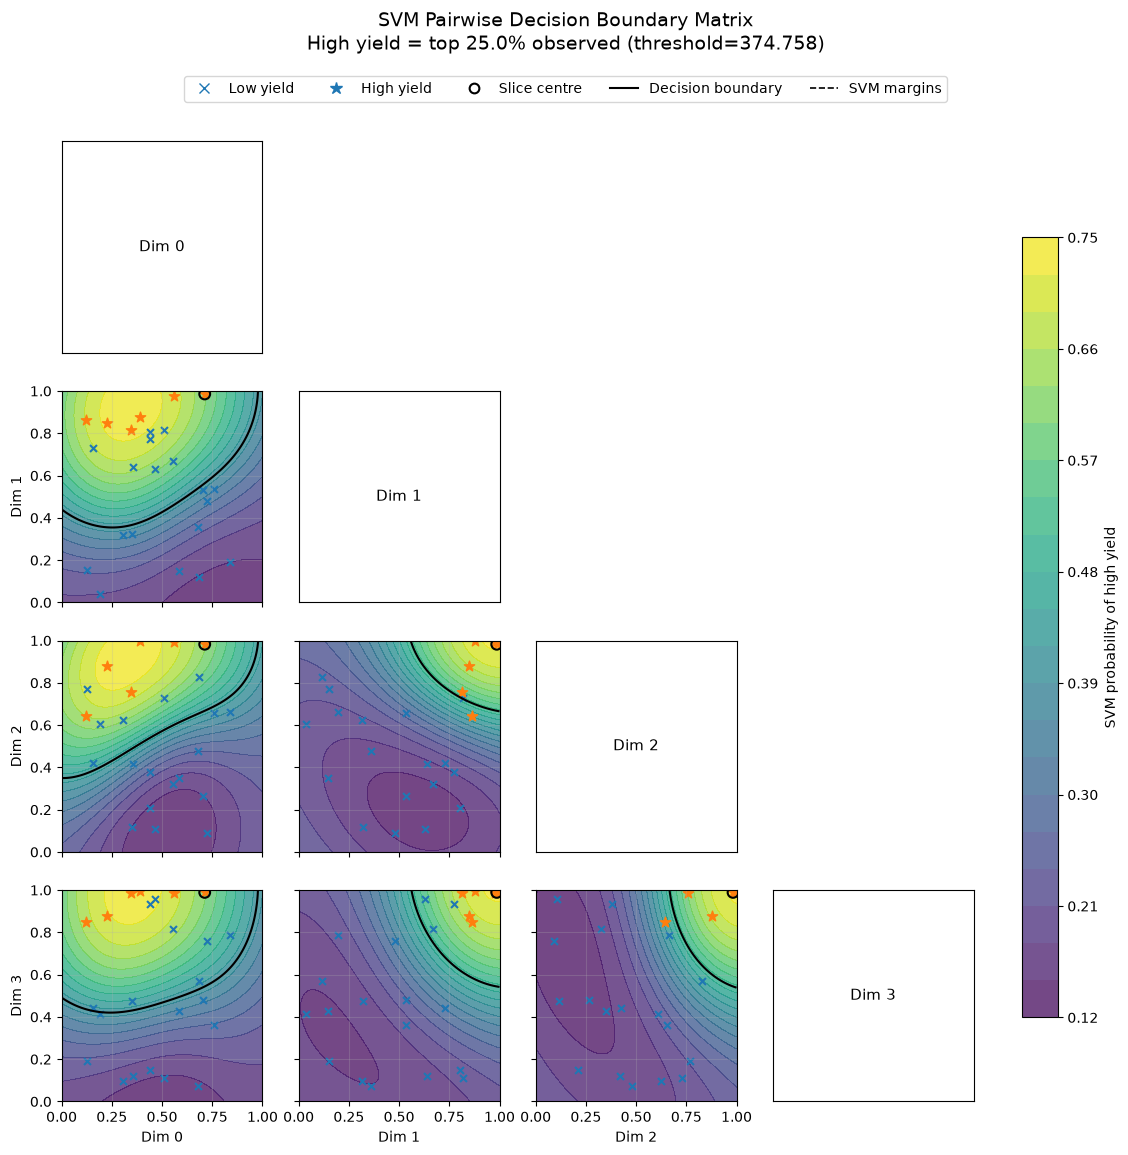

In [11]:
svm_model = None
svm_labels = None
svm_threshold = None
svm_candidate_scores = None
svm_all_candidate_scores = None
num_candidates_before_svm = len(candidates)

if svm_enabled:
    try:
        svm_model, svm_labels, svm_threshold = train_svm_high_yield_classifier(
            load_dataset,
            X,
            y,
            high_yield_percent=svm_high_yield_percent,
            label_mode=svm_label_mode,
            threshold_value=svm_threshold_value
        )

        original_candidates_before_svm = candidates.copy()

        candidates, svm_candidate_scores, svm_all_candidate_scores = filter_candidates_with_svm(
            candidates,
            svm_model,
            keep_fraction=svm_keep_fraction,
            min_probability=svm_min_probability,
            min_keep=svm_min_keep_candidates
        )

        num_candidates_after_threshold_svm = len(candidates)

        candidates, svm_candidate_scores, svm_random_exploration_added = mix_svm_candidates_with_global_exploration(
            svm_candidates=candidates,
            svm_scores=svm_candidate_scores,
            original_candidates=original_candidates_before_svm,
            svm_model=svm_model,
            random_fraction=svm_random_exploration_fraction,
            random_state=0
        )

        num_candidates = len(candidates)

        print("\n================ SVM HIGH-YIELD FILTER APPLIED ================\n")
        print(f"SVM label mode: {svm_label_mode}")
        print(f"High-yield threshold in transformed y-space: {svm_threshold:.6g}")
        print(f"Observed high-yield samples: {int(svm_labels.sum())} / {len(svm_labels)}")
        print(f"Candidates before SVM filter: {num_candidates_before_svm}")
        print(f"Candidates after SVM probability/fallback filter: {num_candidates_after_threshold_svm}")
        print(f"Random global exploration candidates added: {svm_random_exploration_added}")
        print(f"Candidates after SVM + random exploration mix: {num_candidates}")
        print(f"SVM minimum probability threshold: {svm_min_probability:.4f}")
        print(f"SVM minimum fallback keep count: {svm_min_keep_candidates}")
        print(f"Kept candidate SVM probability range: {svm_candidate_scores.min():.4f} to {svm_candidate_scores.max():.4f}")

        if svm_plot_boundary:
            best_observed_input = X[np.argmax(y)]
            plot_svm_decision_boundary_matrix(
                svm_model=svm_model,
                X_train=X,
                y_train=y,
                labels=svm_labels,
                threshold=svm_threshold,
                grid_size=100
            )
            
            
    except Exception as exc:
        print("\nWARNING: SVM filter was requested but could not be applied.")
        print(f"Reason: {exc}")
        print("Continuing with the original unfiltered candidate set.")
else:
    print("\nSVM high-yield filter is disabled for this function.")

Kernal selection :
- Scalar length scale : low dimensions / low data.
- ARD length scale : higher dimensions with enough data.

In [12]:
samples_per_dimension = n_samples / n_dimensions

# change to 4 for more aggressive ARD default was 6
use_ard = (n_dimensions >= 5 and samples_per_dimension >= 6)

if use_ard:
    # Set ARD length scale to 1.0 for each dimension as a starting point
    length_scale = np.ones(n_dimensions)
    kernel_mode = ("ARD length scale")
else:
    # Set scalar length scale based on input dimensionality to provide a reasonable starting point
    scalar_length_scale = (0.10 + 0.05 * n_dimensions)
    length_scale = (scalar_length_scale)
    kernel_mode = (f"Scalar length scale " f"({scalar_length_scale:.3f})")

print(f"Kernel mode: {kernel_mode}")

Kernel mode: Scalar length scale (0.300)


GP hyperparameter tuning :

In [13]:
# Tune GP hyperparameters and get the best configuration and search results for later 
# use in model selection and candidate generation.
best_gp_config, gp_search_results = tune_gp_hyperparameters(
    X=X,
    y=y,
    length_scale=length_scale,
    load_dataset=load_dataset,
    random_state=0
)

selected_kernel_name = best_gp_config["kernel_name"]
selected_alpha_value = best_gp_config["alpha"]
selected_ls_bounds = best_gp_config["length_scale_bounds"]
selected_matern_nu = best_gp_config["matern_nu"]
selected_rq_alpha = best_gp_config["rq_alpha"]

# Keep an ensemble, but bias it around the best model family.
# This avoids throwing away ensemble robustness while still using tuning results.
kernels = {
    selected_kernel_name:
        make_gp_kernel(
            kernel_name=selected_kernel_name,
            length_scale=length_scale,
            length_scale_bounds=selected_ls_bounds,
            matern_nu=selected_matern_nu,
            rq_alpha=0.5 if selected_rq_alpha is None else selected_rq_alpha
        )
}

# Add the next-best distinct kernel families from the search result table.
# This keeps the ensemble diverse without manually choosing kernels.
for row in gp_search_results:
    kernel_name = row["kernel_name"]
    # Skip if this kernel family is already in the ensemble to ensure diversity of kernel types 
    # in the ensemble, which can help improve robustness and performance by combining different 
    # modeling assumptions and characteristics from various kernel types.
    if kernel_name in kernels:
        continue
    # Add the kernel to the ensemble using the hyperparameters from the search results, 
    # allowing us to include the next-best performing kernels based on LOO MSE while maintaining 
    # diversity in the ensemble.
    kernels[kernel_name] = make_gp_kernel(
        kernel_name=kernel_name,
        length_scale=length_scale,
        length_scale_bounds=row["length_scale_bounds"],
        matern_nu=row["matern_nu"],
        rq_alpha=0.5 if row["rq_alpha"] is None else row["rq_alpha"]
    )

    if len(kernels) >= 3:
        break

alpha_by_kernel = {}

# Extract the alpha values for each kernel in the ensemble from the search results to ensure 
# that we are using the appropriate noise level for each kernel based on the hyperparameter 
# tuning results, which can impact the performance of the Gaussian Process models in the ensemble. 
for kernel_name in kernels:
    for row in gp_search_results:
        if row["kernel_name"] == kernel_name:
            alpha_by_kernel[kernel_name] = row["alpha"]
            break

print(
    "\n================ "
    "SELECTED ENSEMBLE KERNELS "
    "=================\n"
)
for kernel_name, kernel in kernels.items():
    print(f"{kernel_name}: alpha={alpha_by_kernel[kernel_name]}, kernel={kernel}")


================================ AUTOMATIC GP HYPERPARAMETER TUNING ==================================

RBF                alpha=1.0e-10   bounds=(0.001, 100.0) nu=None rq_alpha=None LOO MSE=57599.080944
RBF                alpha=1.0e-10   bounds=(0.01, 100.0)  nu=None rq_alpha=None LOO MSE=57599.080935
RBF                alpha=1.0e-10   bounds=(0.02, 100.0)  nu=None rq_alpha=None LOO MSE=57599.081463
RBF                alpha=1.0e-08   bounds=(0.001, 100.0) nu=None rq_alpha=None LOO MSE=57599.056954
RBF                alpha=1.0e-08   bounds=(0.01, 100.0)  nu=None rq_alpha=None LOO MSE=57599.055739
RBF                alpha=1.0e-08   bounds=(0.02, 100.0)  nu=None rq_alpha=None LOO MSE=57599.057572
RBF                alpha=1.0e-06   bounds=(0.001, 100.0) nu=None rq_alpha=None LOO MSE=57596.556841
RBF                alpha=1.0e-06   bounds=(0.01, 100.0)  nu=None rq_alpha=None LOO MSE=57596.557238
RBF                alpha=1.0e-06   bounds=(0.02, 100.0)  nu=None rq_alpha=None LOO MSE=57596.55

Phase 1:
- generate N candidate suggestions.
- For each kernel, fit a Gaussian Process and generate candidates based on UCB and EI acquisition functions

In [14]:
results = {}
trained_models = {}
best_y = np.max(y)

# For each kernel, fit a Gaussian Process and generate candidates based on UCB and EI acquisition functions
for kernel_name, kernel in kernels.items():
    gp = GaussianProcessRegressor(
        kernel=kernel,
        alpha=alpha_by_kernel[kernel_name],
        normalize_y=True,
        n_restarts_optimizer=20,
        random_state=0
    )

    #Fit the Gaussian Process model to the data
    gp.fit(X, y)

    #print out the gp equation and learned kernel parameters for debugging and insight into the model
    print(f"\nTrained GP with {kernel_name} kernel:")
    print(gp)

    #Store the trained model for later use in ensemble predictions
    trained_models[kernel_name] = gp
    #Predict mean and standard deviation for the candidate points using the trained GP model
    mean, std = gp.predict(candidates, return_std=True)

    # ------------------------------
    # UCB
    # ------------------------------

    # Calculate UCB score for each candidate point using the predicted mean and standard deviation,
    # and identify the index of the candidate with the highest UCB score to store the results
    # for this kernel and acquisition function in the results dictionary, including the suggested input, 
    # predicted mean, uncertainty, acquisition score, and learned kernel parameters. This allows us to 
    # compare the suggestions from different acquisition functions for each kernel and understand how 
    # the choice of acquisition function impacts the candidate selection based on the predicted mean 
    # and uncertainty from the Gaussian Process model.       
    ucb_score = ucb(mean, std, beta=2.0)
    #Identify the index of the candidate with the highest UCB score
    idx = np.argmax(ucb_score)

    #Store the results for this kernel and acquisition function in the results dictionary, 
    # including the suggested input, predicted mean, uncertainty, acquisition score, and
    #  learned kernel parameters
    results[f"{kernel_name} + UCB"] = {
        "input":
            candidates[idx],
        "mean":
            mean[idx],
        "std":
            std[idx],
        "score":
            ucb_score[idx],
        "kernel":
            gp.kernel_
    }

    # ------------------------------
    # EI
    # ------------------------------

    # Calculate EI score for each candidate point using the predicted mean and standard deviation,
    # the best observed value, and the exploration parameter xi, and identify the index of the candidate 
    # with the highest EI score to store the results for this kernel and acquisition function in the 
    # results dictionary, including the suggested input, predicted mean, uncertainty, acquisition score, 
    # and learned kernel parameters. This allows us to compare the suggestions from different acquisition 
    # functions for each kernel and understand how the choice of acquisition function impacts the candidate 
    # selection based on the predicted mean and uncertainty from the Gaussian Process model.
    ei_score = expected_improvement(mean, std, best_y, xi=xi )
    #Identify the index of the candidate with the highest EI score
    idx = np.argmax(ei_score)
    #Store the results for this kernel and acquisition function in the results dictionary,
    # including the suggested input, predicted mean, uncertainty, acquisition score, and learned kernel parameters
    results[f"{kernel_name} + EI"] = {
        "input":
            candidates[idx],
        "mean":
            mean[idx],
        "std":
            std[idx],
        "score":
            ei_score[idx],
        "kernel":
            gp.kernel_
    }

    # ------------------------------
    # PI
    # ------------------------------

    # Calculate PI score for each candidate point using the predicted mean and standard deviation,
    # the best observed value, and the exploration parameter xi, and identify the index of the candidate 
    # with the highest PI score to store the results for this kernel and acquisition function in the 
    # results dictionary, including the suggested input, predicted mean, uncertainty, acquisition score, 
    # and learned kernel parameters. This allows us to compare the suggestions from different acquisition 
    # functions for each kernel and understand how the choice of acquisition function impacts the candidate 
    # selection based on the predicted mean and uncertainty from the Gaussian Process model.
    pi_score = probability_improvement(mean, std, best_y, xi=xi)
    idx = np.argmax(pi_score)
    results[f"{kernel_name} + PI"] = {
        "input":
            candidates[idx],
        "mean":
            mean[idx],
        "std":
            std[idx],
        "score":
            pi_score[idx],
        "kernel":
            gp.kernel_
    }

print("\n================ "
        "TRAINING FIT CHECK "
        "=================\n"
)
# Check the training fit of each GP model by predicting the mean and standard deviation for the training data points,   
# and print out the actual output range, predicted mean range, and mean absolute error to assess how well the model 
# is fitting the observed data and to identify any potential issues with underfitting or overfitting.
# Look at Predicted mean min/max to see if the model is capturing the range of the data, and look at mean absolute 
# error to see how close the predictions are to the actual values on average, which can help identify if the model 
# is underfitting (high error) or overfitting (low error but potentially high variance).     
for kernel_name, gp in trained_models.items():
        train_mean, train_std = gp.predict(X, return_std=True)

        print(f"\n{kernel_name} training fit check")
        print("Actual y min/max:", y.min(), y.max())
        print("Predicted mean min/max:", train_mean.min(), train_mean.max())
        print("Mean absolute error:", np.mean(np.abs(train_mean - y)))
        print("Max predicted std on training data:", np.max(train_std))
        print("variance of predicted mean on training data:", np.var(train_mean))

print("\n================ "
        "CANDIDATE SUGGESTIONS "
        "=================\n"
)
print("\nGenerated candidate suggestions from each kernel and acquisition function combination:")
for method, result in results.items():
    print(f"\n{method}: input={result['input'].round(6)}, mean={round(result['mean'], 6)}, std={round(result['std'], 6)}, score={round(result['score'], 6)}")



Trained GP with RationalQuadratic kernel:
GaussianProcessRegressor(alpha=0.001,
                         kernel=1**2 * RationalQuadratic(alpha=0.1, length_scale=0.3),
                         n_restarts_optimizer=20, normalize_y=True,
                         random_state=0)

Trained GP with Matern kernel:
GaussianProcessRegressor(kernel=1**2 * Matern(length_scale=0.3, nu=1.5),
                         n_restarts_optimizer=20, normalize_y=True,
                         random_state=0)

Trained GP with RBF kernel:
GaussianProcessRegressor(alpha=0.001, kernel=1**2 * RBF(length_scale=0.3),
                         n_restarts_optimizer=20, normalize_y=True,
                         random_state=0)

================ TRAINING FIT CHECK =================


RationalQuadratic training fit check
Actual y min/max: 0.1129397953712203 4799.02151222899
Predicted mean min/max: -0.3750027682261816 4792.641972463546
Mean absolute error: 5.6933274790364345
Max predicted std on training data: 42.0330760

Phase 2: Ensemble re-score of the ALL candidates

- Use the trained GPs to predict the mean and std for each candidate input, then combine these predictions to calculate a 
final score for each candidate that balances exploration and exploitation according to the adaptive weights.

- Use all models to predict the mean and std for each candidate and then combine these predictions in a more 
principled way, such as by averaging the predicted means and combining the variances to get an ensemble mean and std for
each candidate instead of the n individual predictions, which can then be used to calculate the final EI and UCB scores 
for a more robust selection of the next input.

- Is looking at re-score of the n candidates from each model and acquisition function combination using the ensemble 
predictions of all models for each candidate a better approach than just looking at the n individual predictions?



In [15]:
all_means = []
all_stds = []

# Loop through each trained GP model and predict the mean and std for all candidate points, storing these predictions for ensemble combination. 
# This allows us to use the predictions from all models in the ensemble to calculate a more robust 
# and principled score for each candidate point based on the combined mean and uncertainty from the different 
# models, rather than relying on individual predictions from each model and acquisition function combination. 
# By combining the predictions, we can better capture the overall trends and uncertainties in the input space, 
# which can lead to better candidate selection for the next input to evaluate.    
for kernel_name, gp in trained_models.items():
    mean, std = gp.predict(candidates, return_std=True)
    all_means.append(mean)
    all_stds.append(std)

# Convert the lists of means and stds to numpy arrays for easier manipulation and combination
all_means = np.array(all_means)
all_stds = np.array(all_stds)

# Combine the predictions from all models to get an ensemble mean and std for each candidate point. 
# The ensemble mean is calculated as the average of the predicted means from all models, while the 
# ensemble std is calculated by combining the variances (squared stds) and the variance of the means 
# to account for both model uncertainty and disagreement among models.
ensemble_mean = all_means.mean(axis=0)

# Combine variances to get ensemble std: average of variances + variance of means to 
# account for model uncertainty and disagreement
ensemble_std = np.sqrt(np.mean(all_stds ** 2, axis=0) + np.var(all_means, axis=0))

print("\n================ "
        "ENSEMBLE PREDICTIONS "
        "=================\n"
)
print(f"Ensemble mean prediction range: {ensemble_mean.min():.6g} to {ensemble_mean.max():.6g}")
print(f"Ensemble std prediction range: {ensemble_std.min():.6g} to {ensemble_std.max():.6g}")



================ ENSEMBLE PREDICTIONS =================

Ensemble mean prediction range: -593.129 to 5046.18
Ensemble std prediction range: 33.0502 to 1028.05


Phase 3: Score all candidates using ensemble predictions
- Calculate the final EI and UCB scores for each candidate using the ensemble mean and std 
  predictions, the best observed value, and the adaptive exploration parameter xi.

- Calculate the final UCB score for each candidate using the ensemble mean and std 
  predictions and the adaptive exploration weight beta.

- Calculate the final PI score for each candidate using the ensemble mean and std predictions,
  the best observed value, and the adaptive exploration parameter xi.

- Normalize the final EI, UCB, and PI scores to a [0, 1] range to allow for fair combination
  of the three acquisition functions according to the adaptive weights.

- Combine the normalized EI, UCB, and PI scores for each candidate using the adaptive 
  optimization and exploration weights to calculate a final score that balances all three
  acquisition functions according to the current stage of optimization.
  Give PI a real contribution. The previous formula made PI weight equal to zero
  because exploitation_weight + exploration_weight always equals 1.

- Identify the index of the candidate with the highest final score, which represents the best
  next input to evaluate according to the ensemble predictions and adaptive acquisition function combination.



Hybrid candidate:
[0.99274105 0.97542863 0.99346426 0.9102209 ]

Thompson candidate:
[0.99274105 0.97542863 0.99346426 0.9102209 ]
Distance: 0.0
Thompson mean: 5046.179924904288
Thompson std: 380.8079942902322


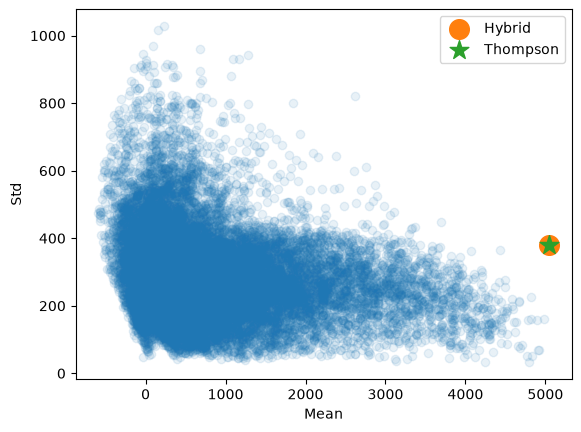


================ FINAL ENSEMBLE SUGGESTION =================

Best next input suggestion: [0.992741 0.975429 0.993464 0.910221]
Ensemble predicted mean at best input: 5046.18
Ensemble predicted std at best input: 380.808
Final combined acquisition score at best input: 0.972784

================ TOP CANDIDATE SUGGESTIONS =================

Number of samples: 24
Input dimensions: 4
Samples per dimension: 6.0
Number of candidates: 19370
Kernel mode: Scalar length scale (0.300)

RationalQuadratic + UCB
----------------------------------------
Suggested next input:
[0.992741 0.975429 0.993464 0.910221]
Predicted mean:
5129.69795
Prediction uncertainty:
345.937008
Acquisition score:
5821.571965
Learned kernel:
4.95**2 * RationalQuadratic(alpha=0.1, length_scale=2.34)

RationalQuadratic + EI
----------------------------------------
Suggested next input:
[0.992741 0.975429 0.993464 0.910221]
Predicted mean:
5129.69795
Prediction uncertainty:
345.937008
Acquisition score:
323.028234
Learned ke

In [16]:
# Calculate the final EI and UCB scores for each candidate using the ensemble mean and std 
# predictions, the best observed value, and the adaptive exploration parameter xi.
ei_final = expected_improvement(
    ensemble_mean,
    ensemble_std,
    best_y,
    xi=xi
)

# Calculate the final UCB score for each candidate using the ensemble mean and std 
# predictions and the adaptive exploration weight beta.
ucb_final = ucb(
    ensemble_mean,
    ensemble_std,
    beta=2.0
)

# Calculate the final PI score for each candidate using the ensemble mean and std predictions,
# the best observed value, and the adaptive exploration parameter xi.
pi_final = probability_improvement(
    ensemble_mean,
    ensemble_std,
    best_y,
    xi=xi
)

# Normalize the final EI, UCB, and PI scores to a [0, 1] range to allow for fair combination
# of the three acquisition functions according to the adaptive weights.
ei_norm = normalize_score(ei_final)
ucb_norm = normalize_score(ucb_final)
pi_norm = normalize_score(pi_final)

# Combine the normalized EI, UCB, and PI scores for each candidate using the adaptive 
# optimization and exploration weights to calculate a final score that balances all three
# acquisition functions according to the current stage of optimization.
# Give PI a real contribution. The previous formula made PI weight equal to zero
# because exploitation + exploration_weight always equals 1.
pi_weight = 0.15
ei_weight = exploitation_weight * (1.0 - pi_weight)
ucb_weight = exploration_weight * (1.0 - pi_weight)

final_score = (
    ei_weight * ei_norm
    + ucb_weight * ucb_norm
    + pi_weight * pi_norm
)

# --------------------------------------------------
# Thompson Sampling acquisition score
# --------------------------------------------------

thompson_samples = []

#for kernel_name, gp in trained_models.items():
#    sample = gp.sample_y(
#        candidates,
#        n_samples=1,
#        random_state=None
#    ).ravel()

#    thompson_samples.append(sample)

#thompson_final_score = np.mean(thompson_samples, axis=0)

from joblib import Parallel, delayed

def fast_sample_one_gp(kernel_name, gp, candidates, seed):
    rng = np.random.default_rng(seed)

    mean, std = gp.predict(
        candidates,
        return_std=True
    )

    sample = rng.normal(
        loc=mean,
        scale=std
    )

    return kernel_name, sample


seeds = np.random.randint(
    0,
    1_000_000,
    size=len(trained_models)
)

thomson_results = Parallel(n_jobs=-1, prefer="threads")(
    delayed(fast_sample_one_gp)(
        kernel_name,
        gp,
        candidates,
        int(seed)
    )
    for (kernel_name, gp), seed in zip(trained_models.items(), seeds)
)

thompson_samples = [
    sample
    for kernel_name, sample in thomson_results
]

thompson_final_score = np.mean(thompson_samples, axis=0)

# Identify the index of the candidate with the highest final score, which represents the best
#  next input to evaluate according to the ensemble predictions and adaptive acquisition function combination.
best_idx = np.argmax(final_score)

best_idx_thompson = np.argmax(thompson_final_score)
best_input_thompson = candidates[best_idx_thompson]

# Select the best next input from the candidates using the identified index of the highest final score.
best_input = candidates[best_idx]

print("Hybrid candidate:")
print(best_input)

print("\nThompson candidate:")
print(best_input_thompson)

distance = np.linalg.norm(
    best_input - best_input_thompson
)

print("Distance:", distance)

print(
    "Thompson mean:",
    ensemble_mean[best_idx_thompson]
)

print(
    "Thompson std:",
    ensemble_std[best_idx_thompson])

plt.scatter(
    ensemble_mean,
    ensemble_std,
    alpha=0.1
)

plt.scatter(
    ensemble_mean[best_idx],
    ensemble_std[best_idx],
    s=200,
    marker="o",
    label="Hybrid"
)

plt.scatter(
    ensemble_mean[best_idx_thompson],
    ensemble_std[best_idx_thompson],
    s=200,
    marker="*",
    label="Thompson"
)

plt.legend()
plt.xlabel("Mean")
plt.ylabel("Std")
plt.show()

    

print("\n================ "
        "FINAL ENSEMBLE SUGGESTION "
        "=================\n"
)
print(f"Best next input suggestion: {best_input.round(6)}")
print(f"Ensemble predicted mean at best input: {ensemble_mean[best_idx]:.6g}")
print(f"Ensemble predicted std at best input: {ensemble_std[best_idx]:.6g}")
print(f"Final combined acquisition score at best input: {final_score[best_idx]:.6g}")

print("\n================ "
        "TOP CANDIDATE SUGGESTIONS "
        "=================\n"
)
print("Number of samples:", n_samples)
print("Input dimensions:", n_dimensions)
print("Samples per dimension:", round(samples_per_dimension, 4))
print("Number of candidates:", num_candidates)
print("Kernel mode:", kernel_mode)
print()
for method, result in results.items():
    print(method)
    print("-" * 40)
    print("Suggested next input:")
    print(result["input"].round(6))
    print("Predicted mean:")
    print(round(result["mean"], 6))
    print("Prediction uncertainty:")
    print(round(result["std"], 6))
    print("Acquisition score:")
    print(round(result["score"], 6))
    print("Learned kernel:")
    print(result["kernel"])
    print()

print(
    "\n================ "
    "FINAL DECISION "
    "=================\n"
)
print("Exploitation weight:", round(exploitation_weight, 4))
print("Exploration weight:", round(exploration_weight, 4))
print("EI final weight:", round(ei_weight, 4))
print("UCB final weight:", round(ucb_weight, 4))
print("PI final weight:", round(pi_weight, 4))
print("Best ensemble mean:", round(ensemble_mean[best_idx], 6))
print("Best ensemble std:", round(ensemble_std[best_idx], 6))
print("Best EI:", round(ei_final[best_idx], 6))
print("Best UCB:", round(ucb_final[best_idx], 6))
print("Best PI:", round(pi_final[best_idx], 6))
print("Final score:", round(final_score[best_idx], 6))

print("Best ensemble candidate:", candidates[best_idx])


Identify which original suggestion is closest to the best ensemble candidate by 
calculating the distance from each original suggestion to the best candidate and 
selecting the one with the smallest distance. This provides insight into which 
kernel and acquisition function combination produced a suggestion that is most 
similar to the final selected input based on the ensemble predictions. 

In [17]:
best_method = None
best_dist = np.inf

for method, result in results.items():
    dist = np.linalg.norm(
        result["input"] - best_input
    )

    if dist < best_dist:
        best_dist = dist
        best_method = method

print(
    f"Closest original suggestion: "
    f"{best_method} "
    f"(distance={best_dist:.6f})"
)

print("\nBEST NEXT INPUT:")
print(best_input.round(6))

print("Estimated output at best input (ensemble mean):", round(ensemble_mean[best_idx], 6))
print("Estimated uncertainty at best input (ensemble std):", round(ensemble_std[best_idx], 6))
print("Estimated EI at best input:", round(ei_final[best_idx], 6))
print("Estimated UCB at best input:", round(ucb_final[best_idx], 6))
print("Estimated PI at best input:", round(pi_final[best_idx], 6))
print("Final acquisition score at best input:", round(final_score[best_idx], 6))

Closest original suggestion: RationalQuadratic + UCB (distance=0.000000)

BEST NEXT INPUT:
[0.992741 0.975429 0.993464 0.910221]
Estimated output at best input (ensemble mean): 5046.179925
Estimated uncertainty at best input (ensemble std): 380.807994
Estimated EI at best input: 271.822783
Estimated UCB at best input: 5807.795913
Estimated PI at best input: 0.699519
Final acquisition score at best input: 0.972784


## Neural-network surrogate comparison

This section adds a small neural-network ensemble as an extra surrogate model. It does **not** replace the GP ensemble. The NN is trained on the same observed samples, then backpropagation is used with respect to the input vector to climb the learned surrogate surface inside the `[0, 1]` search bounds.

Use the result as a comparison candidate, especially for the higher-dimensional functions.

In [18]:
# --------------------------------------------------
# Neural-network surrogate candidate
# --------------------------------------------------
# This is an extra candidate source for comparison against the GP/hybrid result.
# It is deliberately small to reduce overfitting on the small capstone datasets.

use_nn_surrogate = True

if use_nn_surrogate:
    nn_generator = NeuralSurrogateCandidateGenerator(
        n_ensemble=5,
        hidden_units=32,
        activation="tanh",
        #activation="relu",
        learning_rate=1e-3,
        weight_decay=1e-3,
        max_epochs=1500,
        patience=200,
        gradient_steps=80,
        gradient_step_size=0.03,
        random_state=0,
        verbose=False,
    )

    nn_report = nn_generator.suggest(
        X=X,
        y=y,
        candidates=candidates,
        best_gp_input=best_input,
        top_k_starts=32,
        n_random_starts=64,
    )

    print_nn_candidate_report(nn_report)

    nn_candidate = nn_report["candidate"]

    # Score the NN candidate using the already-trained GP ensemble too.
    # This gives an apples-to-apples comparison against the GP/hybrid candidate.
    nn_gp_means = []
    nn_gp_stds = []

    for kernel_name, gp in trained_models.items():
        mean_one, std_one = gp.predict(
            nn_candidate.reshape(1, -1),
            return_std=True,
        )
        nn_gp_means.append(float(mean_one[0]))
        nn_gp_stds.append(float(std_one[0]))

    nn_gp_means = np.asarray(nn_gp_means)
    nn_gp_stds = np.asarray(nn_gp_stds)

    nn_gp_ensemble_mean = float(np.mean(nn_gp_means))
    nn_gp_ensemble_std = float(
        np.sqrt(
            np.mean(nn_gp_stds ** 2)
            + np.var(nn_gp_means)
        )
    )

    print("GP ensemble score at NN candidate")
    print("Mean:", round(nn_gp_ensemble_mean, 6))
    print("Std:", round(nn_gp_ensemble_std, 6))
    print("Distance from GP/hybrid best_input:", round(np.linalg.norm(nn_candidate - best_input), 6))

    print("\nComparison")
    print("GP/hybrid candidate:", np.round(best_input, 6))
    print("NN-gradient candidate:", np.round(nn_candidate, 6))
else:
    nn_report = None
    nn_candidate = None



================ NEURAL SURROGATE CANDIDATE ================
NN candidate:
[1. 1. 1. 1.]
NN predicted mean: 5608.152344
NN ensemble std: 93.07737
NN training RMSE: 32.06945
Distance to best observed: 0.288739
Distance to GP/hybrid candidate: 0.093592
Gradient-ascent starts used: 97

GP ensemble score at NN candidate
Mean: 5508.280562
Std: 394.06498
Distance from GP/hybrid best_input: 0.093592

Comparison
GP/hybrid candidate: [0.992741 0.975429 0.993464 0.910221]
NN-gradient candidate: [1. 1. 1. 1.]


### Neural-network diagnostic plot

For 2D functions, this plots the NN surrogate surface directly. For higher-dimensional functions, it plots a 2D slice through the NN candidate while fixing the other dimensions at the NN candidate value.

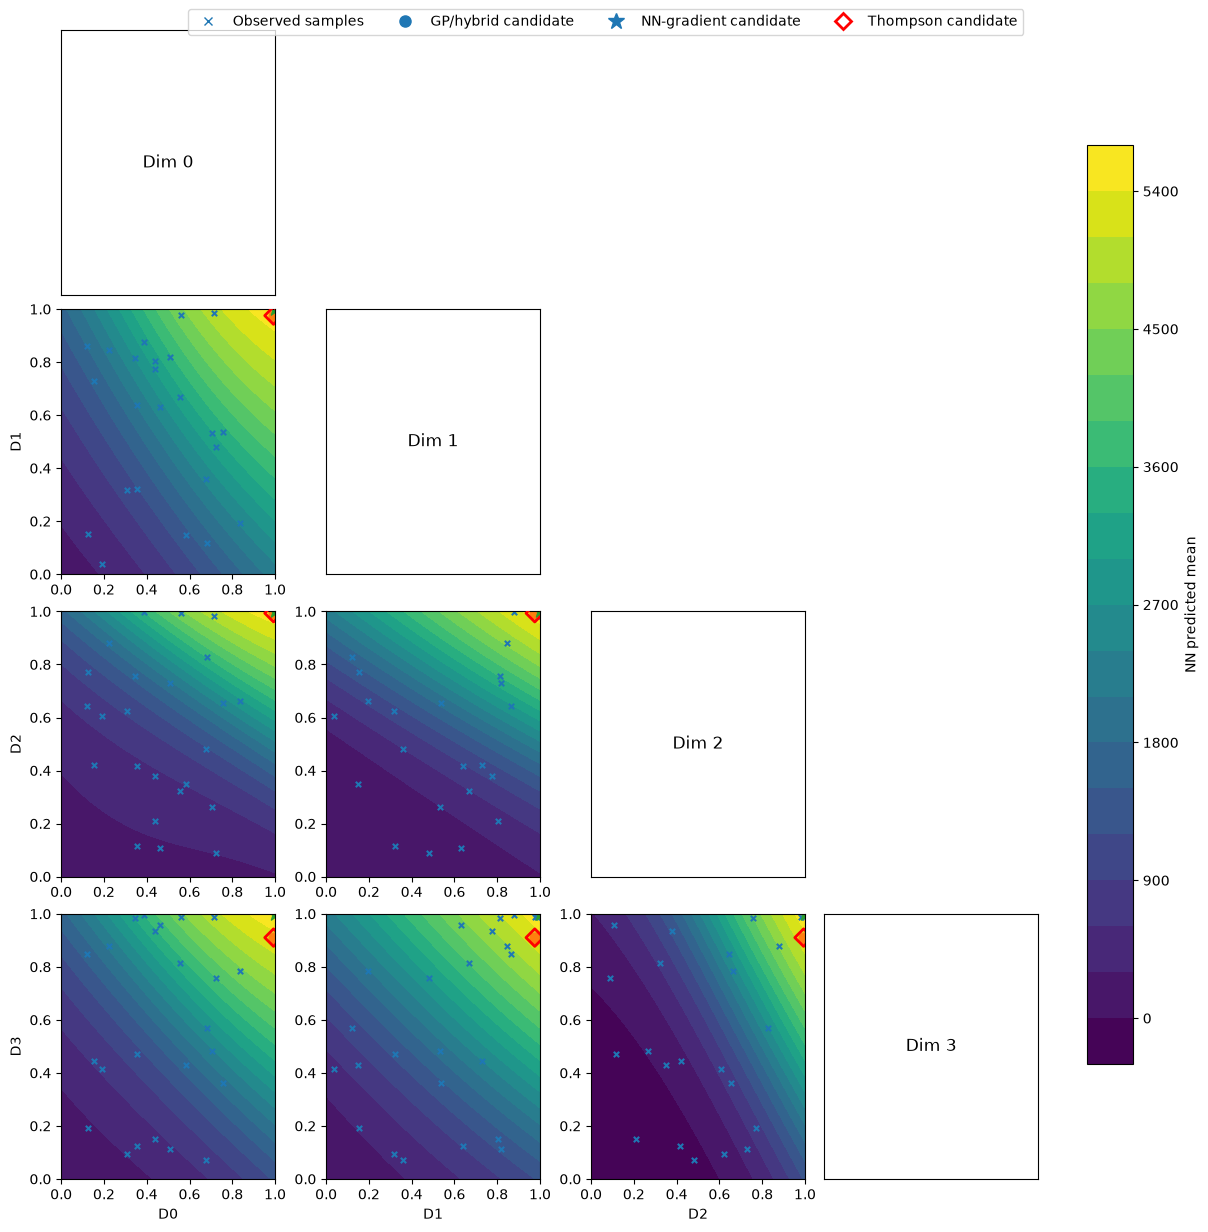

In [19]:
# Optional NN diagnostic surface/slice plot
if use_nn_surrogate and nn_report is not None:
    from matplotlib.lines import Line2D

    grid_size = 80

    # Create figure first
    fig, axes = plt.subplots(
        n_dimensions,
        n_dimensions,
        figsize=(3 * n_dimensions, 3 * n_dimensions),
        constrained_layout=True,
        squeeze=False,
    )

    # Store grids so we don't predict twice
    plot_data = {}
    global_min = np.inf
    global_max = -np.inf

    # Pass 1: compute all NN mean grids and global colour limits
    for dim_i in range(n_dimensions):
        for dim_j in range(dim_i):  # lower triangle only

            xi_grid = np.linspace(0.0, 1.0, grid_size)
            xj_grid = np.linspace(0.0, 1.0, grid_size)
            xx, yy_grid = np.meshgrid(xi_grid, xj_grid)

            X_plot = np.tile(nn_candidate, (grid_size * grid_size, 1))
            X_plot[:, dim_j] = xx.ravel()
            X_plot[:, dim_i] = yy_grid.ravel()

            nn_mean_grid, _ = nn_generator.predict(X_plot, return_std=True)
            nn_mean_grid = nn_mean_grid.reshape(grid_size, grid_size)

            plot_data[(dim_i, dim_j)] = (xx, yy_grid, nn_mean_grid)

            global_min = min(global_min, nn_mean_grid.min())
            global_max = max(global_max, nn_mean_grid.max())

    # Pass 2: plot
    contour = None

    for dim_i in range(n_dimensions):
        for dim_j in range(n_dimensions):

            ax = axes[dim_i, dim_j]

            if dim_i == dim_j:
                ax.text(
                    0.5,
                    0.5,
                    f"Dim {dim_i}",
                    ha="center",
                    va="center",
                    fontsize=12,
                )
                ax.set_xticks([])
                ax.set_yticks([])
                continue

            if dim_j > dim_i:
                ax.axis("off")
                continue

            xx, yy_grid, nn_mean_grid = plot_data[(dim_i, dim_j)]

            contour = ax.contourf(
                xx,
                yy_grid,
                nn_mean_grid,
                levels=20,
                vmin=global_min,
                vmax=global_max,
            )

            ax.scatter(X[:, dim_j], X[:, dim_i], marker="x", s=15)
            ax.scatter(best_input[dim_j], best_input[dim_i], marker="o", s=60)
            ax.scatter(nn_candidate[dim_j], nn_candidate[dim_i], marker="*", s=100)

            ax.scatter(
                best_input_thompson[dim_j],
                best_input_thompson[dim_i],
                marker="D",
                s=80,
                facecolors="none",
                edgecolors="red",
                linewidths=2,
                zorder=10,
            )

            if dim_i == n_dimensions - 1:
                ax.set_xlabel(f"D{dim_j}")

            if dim_j == 0:
                ax.set_ylabel(f"D{dim_i}")

    # Shared colourbar
    fig.colorbar(
        contour,
        ax=axes,
        shrink=0.8,
        label="NN predicted mean",
    )

    # Figure-level legend
    legend_handles = [
        Line2D([], [], marker="x", linestyle="None", label="Observed samples"),
        Line2D([], [], marker="o", linestyle="None", markersize=8, label="GP/hybrid candidate"),
        Line2D([], [], marker="*", linestyle="None", markersize=12, label="NN-gradient candidate"),
        Line2D(
            [],
            [],
            marker="D",
            linestyle="None",
            markersize=8,
            markerfacecolor="none",
            markeredgecolor="red",
            markeredgewidth=2,
            label="Thompson candidate",
        ),
    ]

    fig.legend(
        handles=legend_handles,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.02),
        ncol=4,
    )

    plt.show()


Display diagnostics

TODO LOOK AT ADDING THE THOMSON GUESS ON THE PLOTS

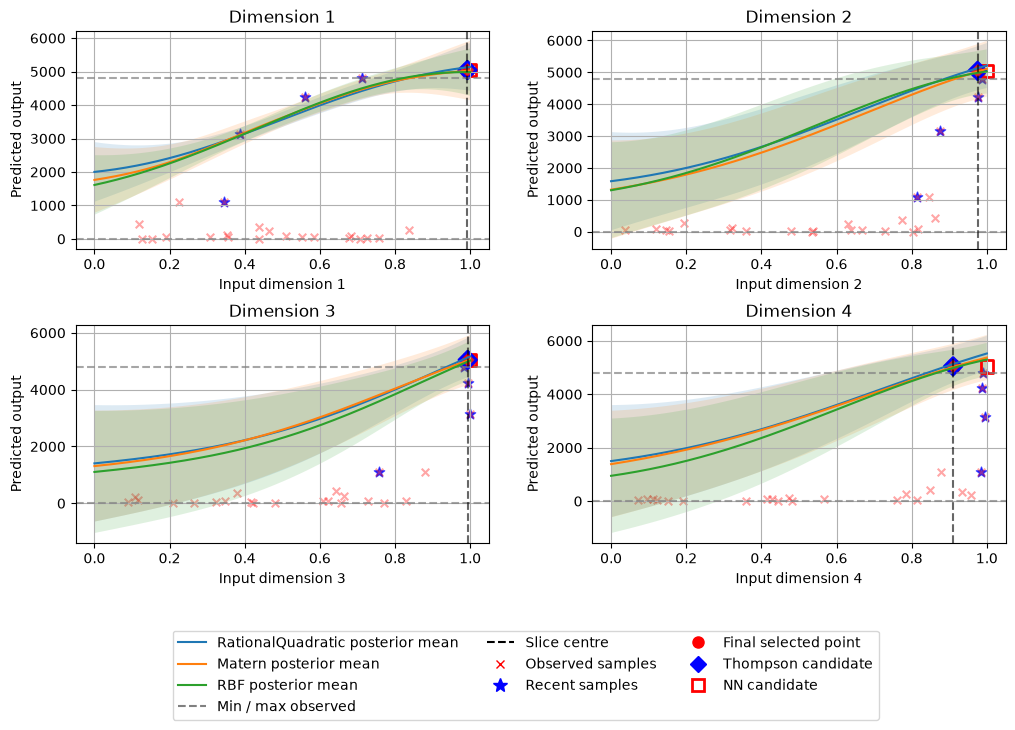

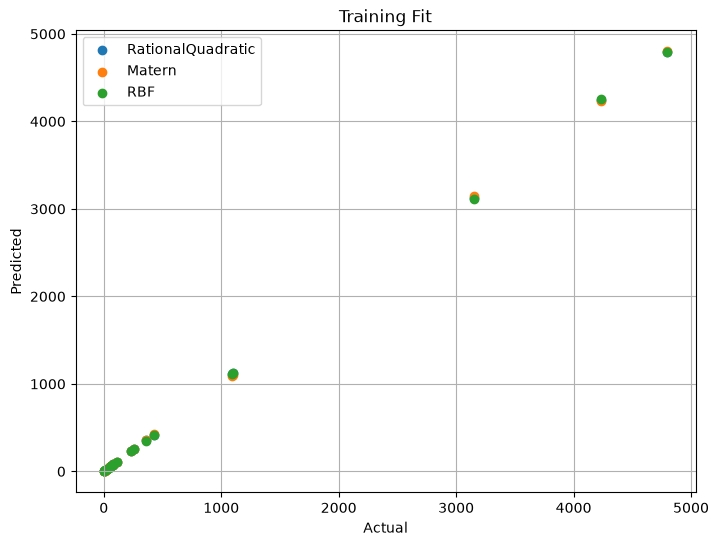

RationalQuadratic max training std: 42.033076031970374
Matern max training std: 0.013335878057021749
RBF max training std: 42.057244866300024


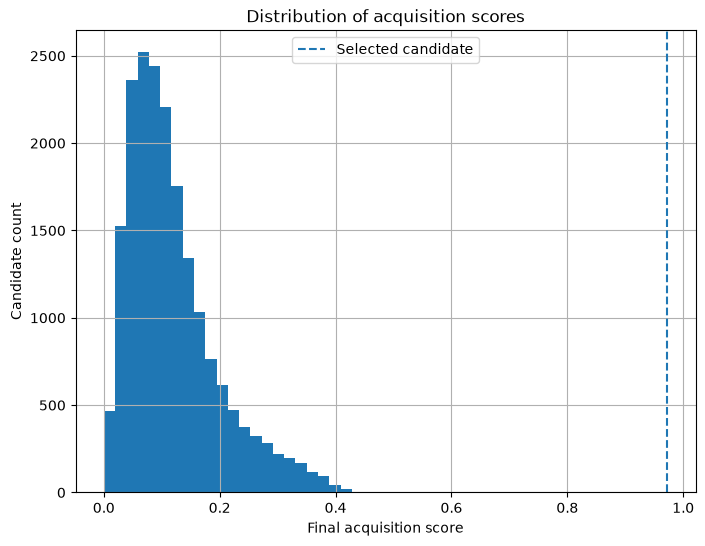

Selected candidate percentile: 100.0000%
Best score: 0.972783776778877
Second best: 0.7917886341586933
Gap: 0.18099514262018368

Top candidates
------------------------------------------------------------
 1: score=0.972784, mean=5046.180, std=380.808, x=[0.99274105 0.97542863 0.99346426 0.9102209 ]
 2: score=0.791789, mean=4982.550, std=160.757, x=[0.85038745 0.98935894 0.95362451 0.98834955]
 3: score=0.680975, mean=4919.789, std=68.902, x=[0.76712213 0.99218543 0.98080672 0.97710074]
 4: score=0.673274, mean=4898.903, std=157.070, x=[0.85003356 0.97565661 0.95120435 0.98284196]
 5: score=0.651037, mean=4903.371, std=68.634, x=[0.76698357 0.98255623 0.98316431 0.97740301]
 6: score=0.629210, mean=4820.967, std=226.405, x=[0.84754437 0.999482   0.99125381 0.89253246]
 7: score=0.576869, mean=4817.113, std=161.314, x=[0.84078015 0.98876444 0.93440376 0.98319515]
 8: score=0.538033, mean=4781.528, std=157.556, x=[0.83826301 0.9391191  0.95241917 0.99046289]
 9: score=0.502910, mean=4831

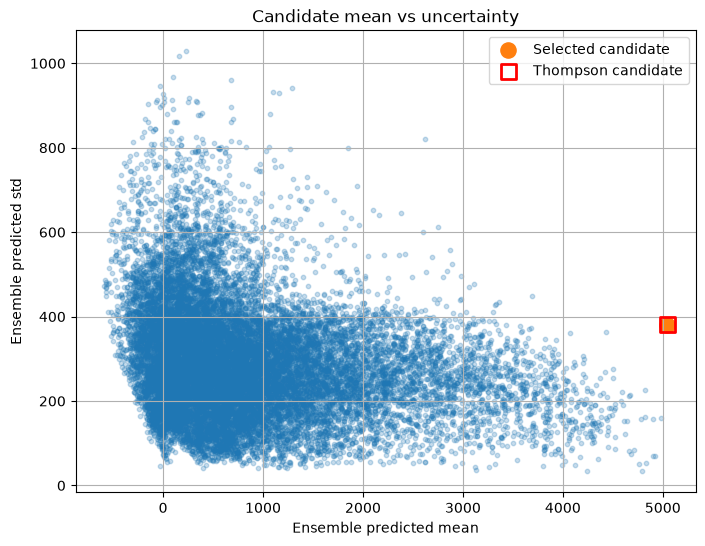

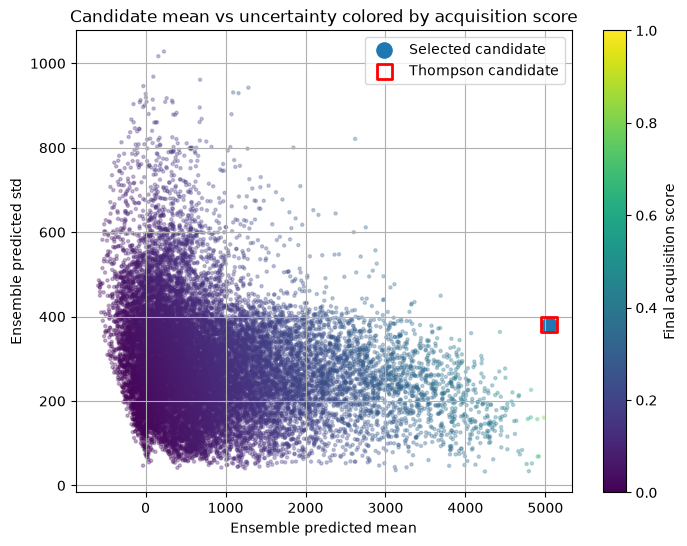

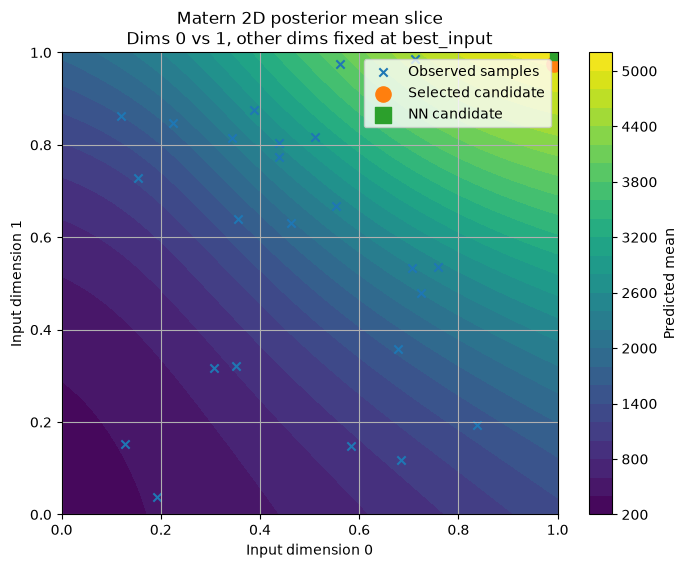

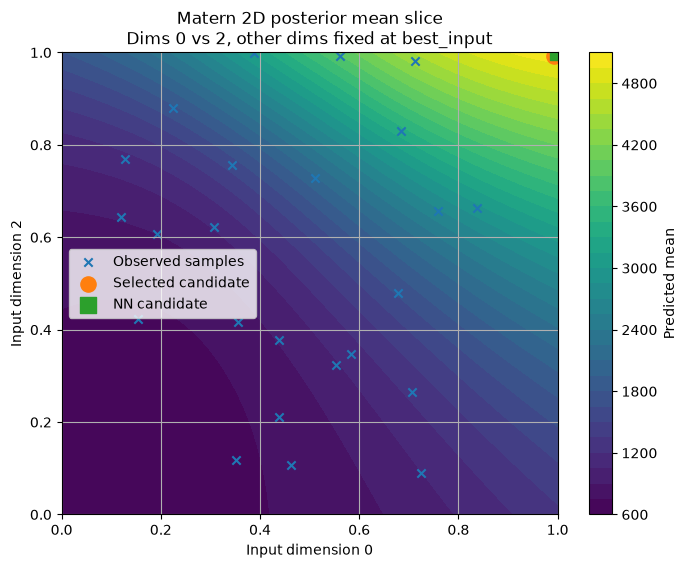

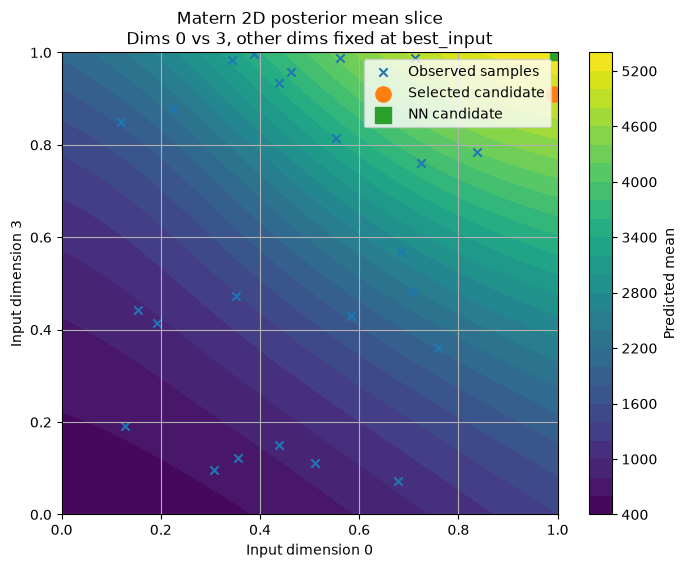

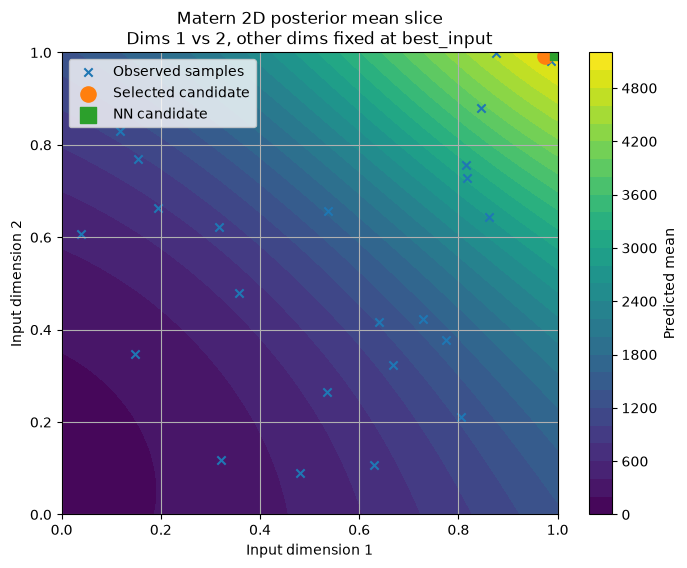

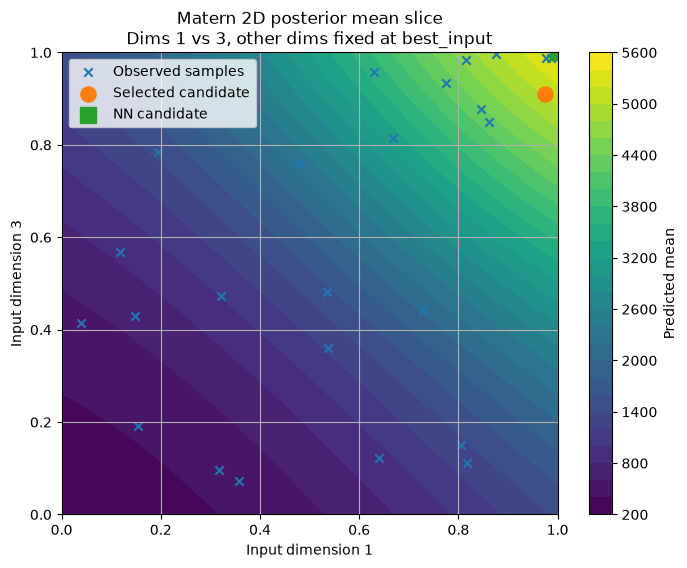

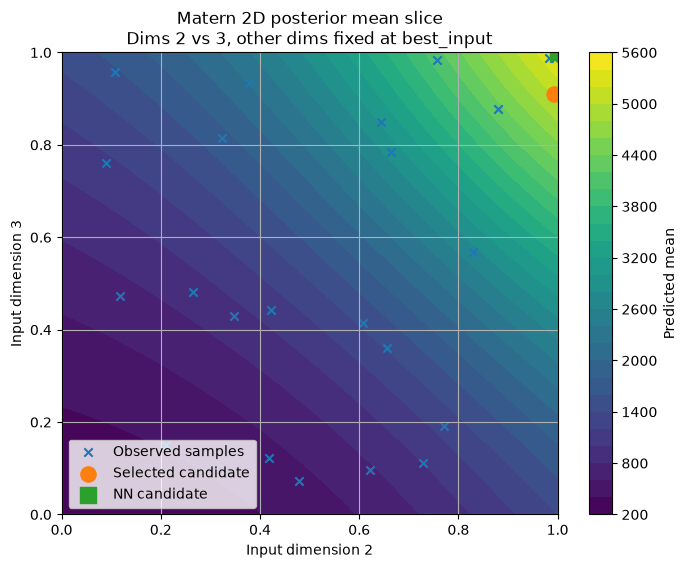


Process complete.


In [20]:
from src.gp_diagnostics import run_gp_diagnostics

run_gp_diagnostics(
    X=X,
    y=y,
    trained_models=trained_models,
    best_input=best_input,
    NN_best_input=nn_candidate,
    Thompson_best_input=best_input_thompson,
    ensemble_mean=ensemble_mean,
    ensemble_std=ensemble_std,
    final_score=final_score,
    best_idx=best_idx,
    thompson_best_idx=best_idx_thompson,
    candidates=candidates,
    week_dataset=week_dataset,
    n_dimensions=n_dimensions,
)